# EEGMMIDB PyTorch Pipeline (Subject-Independent)

This notebook builds and evaluates a generalized cross-subject motor imagery classifier.

Pipeline:
- discover local EDF recordings by subject/run
- preprocess raw EEG
- epoch around motor imagery cues
- build subject-independent train/val split (no subject leakage)
- train EEGNet-style CNN and evaluate



In [1]:
# Uncomment if your environment is missing dependencies
%pip install mne torch numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import mne
from mne.datasets import eegbci

mne.set_log_level("WARNING")
print("torch:", torch.__version__)
print("mne:", mne.__version__)


torch: 2.11.0+cpu
mne: 1.12.1


In [3]:
# -----------------------
# Configuration
# -----------------------
DATA_ROOT = Path("./MNE-eegbci-data/files/eegmmidb/1.0.0")

# Choose one task setup:
# - 'left_right': runs 4, 8, 12 (T1=left fist imagery, T2=right fist imagery)
# - 'hands_feet': runs 6, 10, 14 (T1=both fists imagery, T2=both feet imagery)
TASK = "left_right"

RUNS_BY_TASK = {
    "left_right": [4, 8, 12],
    "hands_feet": [6, 10, 14],
}

EVENT_MAP_BY_TASK = {
    "left_right": {"T1": "left_fist", "T2": "right_fist"},
    "hands_feet": {"T1": "both_fists", "T2": "both_feet"},
}

SUBJECT_IDS = list(range(1, 110))  # 1..109
MAX_FILES = None  # set e.g. 30 for fast debugging

L_FREQ, H_FREQ = 7.0, 30.0
TARGET_SFREQ = 128.0  # unify sample rate across EDF files
EPOCH_WINDOW = (0.5, 3.5)  # MI-focused default; try (1.0, 4.0) too
TMIN, TMAX = EPOCH_WINDOW

VAL_SUBJECT_FRACTION = 0.2
RANDOM_STATE = 42
BATCH_SIZE = 64
NUM_WORKERS = 0

assert DATA_ROOT.exists(), f"Missing data directory: {DATA_ROOT.resolve()}"
assert TASK in RUNS_BY_TASK

print("Data root:", DATA_ROOT.resolve())
print("Task:", TASK, "Runs:", RUNS_BY_TASK[TASK])
print("Epoch window (s):", (TMIN, TMAX), "| Target sfreq:", TARGET_SFREQ)


Data root: C:\Users\Kades\Documents\MAU\AML GP\BCI\MNE-eegbci-data\files\eegmmidb\1.0.0
Task: left_right Runs: [4, 8, 12]
Epoch window (s): (0.5, 3.5) | Target sfreq: 128.0


In [4]:
def extract_run_number(edf_path: Path) -> int:
    stem = edf_path.stem.upper()
    # Expected EEGMMIDB format: S001R04
    if "R" in stem:
        run_part = stem.rsplit("R", 1)[-1]
        if run_part.isdigit() and len(run_part) == 2:
            return int(run_part)

    m = re.search("R([0-9]{2})", stem)
    if m is None:
        raise ValueError(f"Could not parse run id from: {edf_path.name}")
    return int(m.group(1))


def discover_edf_files(data_root: Path, subject_ids, runs, max_files=None):
    run_set = set(runs)
    files = []

    for sid in subject_ids:
        subject_dir = data_root / f"S{sid:03d}"
        if not subject_dir.exists():
            continue

        for edf_path in sorted(subject_dir.glob("*.edf")):
            run_no = extract_run_number(edf_path)
            if run_no in run_set:
                files.append(edf_path)

    files = sorted(files)
    if max_files is not None:
        files = files[:max_files]

    return files


def preprocess_raw(raw: mne.io.BaseRaw, event_rename_map, l_freq=7.0, h_freq=30.0, target_sfreq=128.0):
    eegbci.standardize(raw)
    raw.set_montage(mne.channels.make_standard_montage("standard_1005"), on_missing="warn")
    raw.set_eeg_reference(projection=True)
    if target_sfreq is not None and abs(raw.info["sfreq"] - target_sfreq) > 1e-6:
        raw.resample(target_sfreq)
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design="firwin", skip_by_annotation="edge")

    # Map PhysioNet event codes (T1/T2) into task-specific labels
    raw.annotations.rename(event_rename_map)
    return raw


def epochs_from_raw(raw: mne.io.BaseRaw, event_map, tmin=0.0, tmax=4.0):
    events, full_event_id = mne.events_from_annotations(raw, verbose=False)
    wanted_labels = list(event_map.values())
    event_id = {label: full_event_id[label] for label in wanted_labels if label in full_event_id}

    if not event_id:
        return None, None

    keep_ids = set(event_id.values())
    mask = np.isin(events[:, -1], list(keep_ids))
    events = events[mask]
    if len(events) == 0:
        return None, None

    picks = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        proj=True,
        picks=picks,
        verbose=False,
    )
    return epochs, event_id


In [5]:
def subject_id_from_edf_path(edf_path: Path) -> int:
    # Expected subject folder format: S001, S002, ...
    m = re.search(r"S([0-9]{3})", edf_path.parent.name.upper())
    if m is not None:
        return int(m.group(1))

    # Fallback: parse from filename stem if needed.
    m = re.search(r"S([0-9]{3})", edf_path.stem.upper())
    if m is None:
        raise ValueError(f"Could not parse subject id from: {edf_path}")
    return int(m.group(1))


def build_epoch_arrays(edf_files, event_map, l_freq, h_freq, tmin, tmax, target_sfreq=128.0):
    X_chunks = []
    y_chunks = []
    subj_chunks = []
    observed_event_id = None

    for i, edf_path in enumerate(edf_files, start=1):
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        raw = preprocess_raw(raw, event_map, l_freq=l_freq, h_freq=h_freq, target_sfreq=target_sfreq)

        epochs, event_id = epochs_from_raw(raw, event_map, tmin=tmin, tmax=tmax)
        if epochs is None:
            continue
        if observed_event_id is None:
            observed_event_id = event_id

        X = epochs.get_data(copy=False).astype(np.float32)  # (n_epochs, n_channels, n_times)
        y = epochs.events[:, -1].astype(np.int64)
        sid = subject_id_from_edf_path(edf_path)
        subj = np.full(shape=(len(y),), fill_value=sid, dtype=np.int32)

        X_chunks.append(X)
        y_chunks.append(y)
        subj_chunks.append(subj)

        if i % 20 == 0:
            print(f"Processed {i}/{len(edf_files)} files")

    if not X_chunks:
        raise RuntimeError("No epochs were extracted. Check task/runs/data path.")

    X_all = np.concatenate(X_chunks, axis=0)
    y_all = np.concatenate(y_chunks, axis=0)
    subject_ids = np.concatenate(subj_chunks, axis=0)

    # map event ids to {0,1,...}
    unique_ids = np.unique(y_all)
    id_to_class = {eid: idx for idx, eid in enumerate(unique_ids)}
    y_all = np.vectorize(id_to_class.get)(y_all).astype(np.int64)

    # CNN-friendly shape: (N, 1, C, T)
    X_all = X_all[:, np.newaxis, :, :]

    class_to_label = {}
    if observed_event_id is not None:
        label_by_event_id = {eid: label for label, eid in observed_event_id.items()}
        class_to_label = {id_to_class[eid]: label_by_event_id.get(eid, str(eid)) for eid in unique_ids}

    return X_all, y_all, subject_ids, id_to_class, class_to_label


In [6]:
class EEGTorchDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


edf_files = discover_edf_files(
    data_root=DATA_ROOT,
    subject_ids=SUBJECT_IDS,
    runs=RUNS_BY_TASK[TASK],
    max_files=MAX_FILES,
)

print(f"Found {len(edf_files)} EDF files for task '{TASK}'.")
print("Example file:", edf_files[0] if edf_files else "None")

X, y, subject_ids, id_to_class, class_to_label = build_epoch_arrays(
    edf_files=edf_files,
    event_map=EVENT_MAP_BY_TASK[TASK],
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    target_sfreq=TARGET_SFREQ,
    tmin=TMIN,
    tmax=TMAX,
)

print("X shape (N,1,C,T):", X.shape)
print("y shape:", y.shape)
print("Subject ids shape:", subject_ids.shape, "| unique subjects:", len(np.unique(subject_ids)))
print("class map (event_id -> class_index):", id_to_class)
print("class labels (class_index -> label):", class_to_label)


Found 327 EDF files for task 'left_right'.
Example file: MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf
Processed 20/327 files
Processed 40/327 files
Processed 60/327 files
Processed 80/327 files
Processed 100/327 files
Processed 120/327 files
Processed 140/327 files
Processed 160/327 files
Processed 180/327 files
Processed 200/327 files
Processed 220/327 files
Processed 240/327 files
Processed 260/327 files
Processed 280/327 files


C:\Users\Kades\AppData\Local\Temp\ipykernel_38964\3535381901.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Kades\AppData\Local\Temp\ipykernel_38964\3535381901.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Kades\AppData\Local\Temp\ipykernel_38964\3535381901.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Processed 300/327 files
Processed 320/327 files
X shape (N,1,C,T): (4917, 1, 64, 385)
y shape: (4917,)
Subject ids shape: (4917,) | unique subjects: 109
class map (event_id -> class_index): {np.int64(2): 0, np.int64(3): 1}
class labels (class_index -> label): {0: 'left_fist', 1: 'right_fist'}


In [7]:
# -----------------------
# Split utilities + Option A (subject-independent, generalized)
# -----------------------
def subject_level_split_indices(subject_ids: np.ndarray, val_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    unique_subjects = np.unique(subject_ids)
    shuffled = unique_subjects.copy()
    rng.shuffle(shuffled)

    n_val_subjects = max(1, int(round(len(shuffled) * val_fraction)))
    val_subjects = shuffled[:n_val_subjects]
    train_subjects = shuffled[n_val_subjects:]

    val_mask = np.isin(subject_ids, val_subjects)
    train_mask = ~val_mask

    train_idx = np.where(train_mask)[0]
    val_idx = np.where(val_mask)[0]

    if len(train_idx) == 0 or len(val_idx) == 0:
        raise RuntimeError("Subject-level split produced an empty train or val set.")

    overlap = set(train_subjects).intersection(set(val_subjects))
    if overlap:
        raise RuntimeError(f"Leakage detected. Overlapping subjects: {sorted(overlap)}")

    return train_idx, val_idx, train_subjects, val_subjects


def stratified_epoch_split_indices(y: np.ndarray, val_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_idx = []
    val_idx = []

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        n_val = max(1, int(round(len(cls_idx) * val_fraction)))
        val_idx.append(cls_idx[:n_val])
        train_idx.append(cls_idx[n_val:])

    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


def fit_channel_zscore(X_train: np.ndarray, eps=1e-6):
    # X shape: (N, 1, C, T)
    mean = X_train.mean(axis=(0, 1, 3), keepdims=True)
    std = X_train.std(axis=(0, 1, 3), keepdims=True)
    std = np.maximum(std, eps)
    return mean.astype(np.float32), std.astype(np.float32)


def apply_channel_zscore(X: np.ndarray, mean: np.ndarray, std: np.ndarray):
    return ((X - mean) / std).astype(np.float32)


def make_dataloaders(X_train, y_train, X_val, y_val, batch_size, num_workers):
    train_ds = EEGTorchDataset(X_train, y_train)
    val_ds = EEGTorchDataset(X_val, y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )
    return train_ds, val_ds, train_loader, val_loader


# Option A: generalized subject-independent split (default)
train_idx, val_idx, train_subjects, val_subjects = subject_level_split_indices(
    subject_ids,
    val_fraction=VAL_SUBJECT_FRACTION,
    seed=RANDOM_STATE,
)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

# Fit on train only, then apply to all splits.
channel_mean, channel_std = fit_channel_zscore(X_train)
X_train = apply_channel_zscore(X_train, channel_mean, channel_std)
X_val = apply_channel_zscore(X_val, channel_mean, channel_std)

train_ds, val_ds, train_loader, val_loader = make_dataloaders(
    X_train, y_train, X_val, y_val, BATCH_SIZE, NUM_WORKERS
)

ACTIVE_PROTOCOL = "subject_independent"
print("Active protocol:", ACTIVE_PROTOCOL)
print("Train subjects:", len(train_subjects), "| Val subjects:", len(val_subjects))
print("No-leakage check (intersection size):", len(set(train_subjects).intersection(set(val_subjects))))
print("Normalization stats shape:", channel_mean.shape, channel_std.shape)
print("Train mean/std check (avg across channels):",
      float(X_train.mean(axis=(0, 1, 3)).mean()),
      float(X_train.std(axis=(0, 1, 3)).mean()))
print("Train/Val epoch counts:", len(train_ds), len(val_ds))
print("Train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("Batch X:", tuple(next(iter(train_loader))[0].shape))



Active protocol: subject_independent
Train subjects: 87 | Val subjects: 22
No-leakage check (intersection size): 0
Normalization stats shape: (1, 1, 64, 1) (1, 1, 64, 1)
Train mean/std check (avg across channels): -2.6372620753889464e-10 1.0
Train/Val epoch counts: 3927 990
Train class counts: {np.int64(0): np.int64(1979), np.int64(1): np.int64(1948)}
Val class counts: {np.int64(0): np.int64(500), np.int64(1): np.int64(490)}
Batch X: (64, 1, 64, 385)


## Baseline EEGNet-Style CNN

This section defines a compact EEGNet-style model and runs a short training loop with validation accuracy and confusion matrix.


Epoch 01/30 | lr=1.00e-03 | train_loss=0.6983 train_acc=0.5210 | val_loss=0.6926 val_acc=0.5232 val_bal_acc=0.5240
Epoch 02/30 | lr=1.00e-03 | train_loss=0.6878 train_acc=0.5335 | val_loss=0.6905 val_acc=0.5788 val_bal_acc=0.5790
Epoch 03/30 | lr=1.00e-03 | train_loss=0.6728 train_acc=0.5668 | val_loss=0.7020 val_acc=0.5889 val_bal_acc=0.5869
Epoch 04/30 | lr=1.00e-03 | train_loss=0.6522 train_acc=0.5903 | val_loss=0.7677 val_acc=0.6162 val_bal_acc=0.6158
Epoch 05/30 | lr=1.00e-03 | train_loss=0.6418 train_acc=0.6050 | val_loss=0.7637 val_acc=0.6182 val_bal_acc=0.6178
Epoch 06/30 | lr=1.00e-03 | train_loss=0.6351 train_acc=0.6226 | val_loss=0.7530 val_acc=0.6030 val_bal_acc=0.6042
Epoch 07/30 | lr=1.00e-03 | train_loss=0.6222 train_acc=0.6290 | val_loss=0.8054 val_acc=0.6010 val_bal_acc=0.6023
Epoch 08/30 | lr=1.00e-03 | train_loss=0.6188 train_acc=0.6379 | val_loss=0.7881 val_acc=0.5879 val_bal_acc=0.5891
Epoch 09/30 | lr=1.00e-03 | train_loss=0.6139 train_acc=0.6407 | val_loss=0.8035

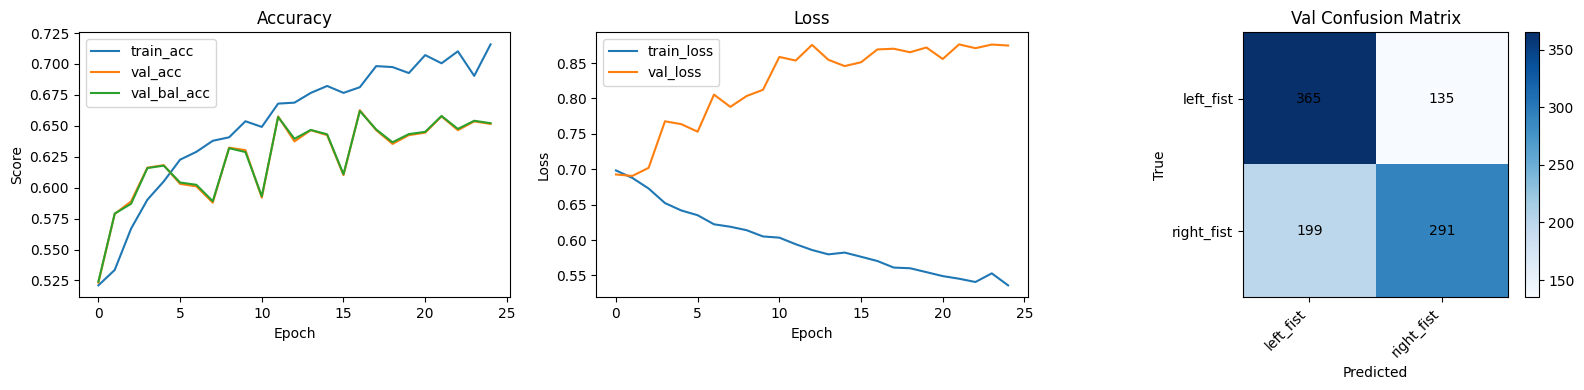

In [ ]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


class EEGNetLite(nn.Module):
    def __init__(
        self,
        n_channels: int,
        n_times: int,
        n_classes: int,
        f1: int = 16,
        d: int = 2,
        f2: int = 32,
        kernel_length: int = 64,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, kernel_size=(1, kernel_length), padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(f1),
            nn.Conv2d(f1, f1 * d, kernel_size=(n_channels, 1), groups=f1, bias=False),
            nn.BatchNorm2d(f1 * d),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(f1 * d, f1 * d, kernel_size=(1, 16), padding=(0, 8), groups=f1 * d, bias=False),
            nn.Conv2d(f1 * d, f2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            feats = self.block2(self.block1(dummy))
            feat_dim = feats.reshape(1, -1).shape[1]

        self.classifier = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.reshape(x.size(0), -1)
        return self.classifier(x)


def confusion_matrix_np(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm


def balanced_accuracy_from_cm(cm: np.ndarray):
    recalls = []
    for i in range(cm.shape[0]):
        denom = cm[i, :].sum()
        recalls.append(0.0 if denom == 0 else cm[i, i] / denom)
    return float(np.mean(recalls))


def evaluate(model, loader, criterion, device, n_classes: int):
    model.eval()
    total_loss = 0.0
    total = 0
    correct = 0
    all_true = []
    all_pred = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * yb.size(0)
            total += yb.size(0)
            correct += (preds == yb).sum().item()

            all_true.append(yb.detach().cpu().numpy())
            all_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    cm = confusion_matrix_np(y_true, y_pred, n_classes=n_classes)

    avg_loss = total_loss / total
    acc = correct / total
    bal_acc = balanced_accuracy_from_cm(cm)
    return avg_loss, acc, bal_acc, y_true, y_pred, cm


# -----------------------
# Train improved baseline model
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_channels = X_train.shape[2]
n_times = X_train.shape[3]
n_classes = len(np.unique(y_train))

model = EEGNetLite(
    n_channels=n_channels,
    n_times=n_times,
    n_classes=n_classes,
    f1=16,
    d=2,
    f2=32,
    kernel_length=64,
    dropout=0.4,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

EPOCHS = 30
EARLY_STOPPING_PATIENCE = 30
MODEL_CKPT_PATH = f"best_eegnet_lite_{ACTIVE_PROTOCOL}.pt"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "lr": [],
}

best_bal_acc = -np.inf
best_epoch = -1
best_state = None
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_total = 0
    running_correct = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        running_loss += loss.item() * yb.size(0)
        running_total += yb.size(0)
        running_correct += (preds == yb).sum().item()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_acc, val_bal_acc, y_val_true, y_val_pred, cm_val = evaluate(
        model,
        val_loader,
        criterion,
        device,
        n_classes=n_classes,
    )

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["lr"].append(current_lr)

    improved = val_bal_acc > best_bal_acc + 1e-6
    if improved:
        best_bal_acc = val_bal_acc
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, MODEL_CKPT_PATH)
        no_improve = 0
    else:
        no_improve += 1

    scheduler.step(val_bal_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"lr={current_lr:.2e} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_bal_acc={val_bal_acc:.4f}"
    )

    if no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is None:
    raise RuntimeError("Training finished without a valid checkpoint.")

model.load_state_dict(best_state)
final_val_loss, final_val_acc, final_val_bal_acc, y_val_true, y_val_pred, cm = evaluate(
    model,
    val_loader,
    criterion,
    device,
    n_classes=n_classes,
)

labels = [class_to_label.get(i, str(i)) for i in range(n_classes)]
print("\nBest epoch:", best_epoch)
print("Best/Final val balanced accuracy:", f"{final_val_bal_acc:.4f}")
print("Best/Final val accuracy:", f"{final_val_acc:.4f}")
print("Checkpoint:", MODEL_CKPT_PATH)
print("\nValidation confusion matrix (rows=true, cols=pred):")
print(cm)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_acc"], label="train_acc")
axes[0].plot(history["val_acc"], label="val_acc")
axes[0].plot(history["val_bal_acc"], label="val_bal_acc")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].plot(history["train_loss"], label="train_loss")
axes[1].plot(history["val_loss"], label="val_loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title("Val Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_xticks(range(n_classes))
axes[2].set_yticks(range(n_classes))
axes[2].set_xticklabels(labels, rotation=45, ha="right")
axes[2].set_yticklabels(labels)

for r in range(n_classes):
    for c in range(n_classes):
        axes[2].text(c, r, str(cm[r, c]), ha="center", va="center", color="black")

fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## Notes
- This notebook is for strict cross-subject evaluation.
- Expected accuracy is usually much lower than subject-dependent evaluation.
- For quick tests, set `MAX_FILES = 10`.

